# Confirmatory Results: Learning Driver Zone Preferences

## tl;dr

A hierarchical pairwise zone-preference model was fitted on 4,270 historical routes. Its preference weight was selected using 916 chronological validation routes under a predeclared constraint: median supplied-travel-time increase must be at most 5% versus nearest neighbour. The locked model was then evaluated once on 926 untouched test routes.

The exact route score follows the official 2021 Amazon Last Mile Routing Research Challenge definition (lower is better). All headline values below are recomputed from committed route-level result tables.

## Context & Methods

The model learns how often one delivery zone precedes another, with station-level estimates backed off to parent-zone and global estimates when support is sparse. At construction time, a tunable preference score is combined with supplied travel time. Once a zone is entered, all of its stops are exhausted to prevent zone re-entry. The mathematical notebook derives this local decision rule and separates the structural contiguity constraint from the learned zone ordering.

- Split: station-aware chronological 70/15/15 train/validation/test.
- Selection: lowest validation median pairwise disagreement among weights satisfying the 5% median travel-time guardrail.
- Confirmatory set: 926 test routes, untouched during model and hyperparameter development.
- Comparators: observed driver, nearest neighbour, and angular zone sweep.
- Primary confirmatory metric: official Amazon route score (lower is better).
- Operational metrics: supplied travel time, zone re-entries, runtime, pairwise disagreement, and adjacent-edge recall.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "pyproject.toml").exists()
    and (candidate / "src" / "lastmile").exists()
)
SOURCE = ROOT / "artifacts" / "travel_time_experiment"
OUT = ROOT / "artifacts" / "confirmatory_results"
OUT.mkdir(parents=True, exist_ok=True)

validation = pd.read_csv(SOURCE / "validation_route_results.csv")
validation_weights = pd.read_csv(SOURCE / "validation_weight_summary.csv")
test = pd.read_csv(SOURCE / "test_route_results.csv")
metadata = json.loads((SOURCE / "run_metadata.json").read_text(encoding="utf-8"))
selected_weight = float(metadata["selected_preference_weight"])

BLUE = "#2F6BFF"
GOLD = "#D69E00"
INK = "#202733"
GREY = "#A9B0BA"
LIGHT_BLUE = "#C7D8FF"
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "font.size": 10,
    "axes.titleweight": "bold",
    "axes.edgecolor": INK,
    "text.color": INK,
    "axes.labelcolor": INK,
    "xtick.color": INK,
    "ytick.color": INK,
})

## Results

### 1. Validation-only selection

The guardrail and model weight were fixed before inspecting the test outcomes. The chart shows the empirical trade-off at all seven declared weights.

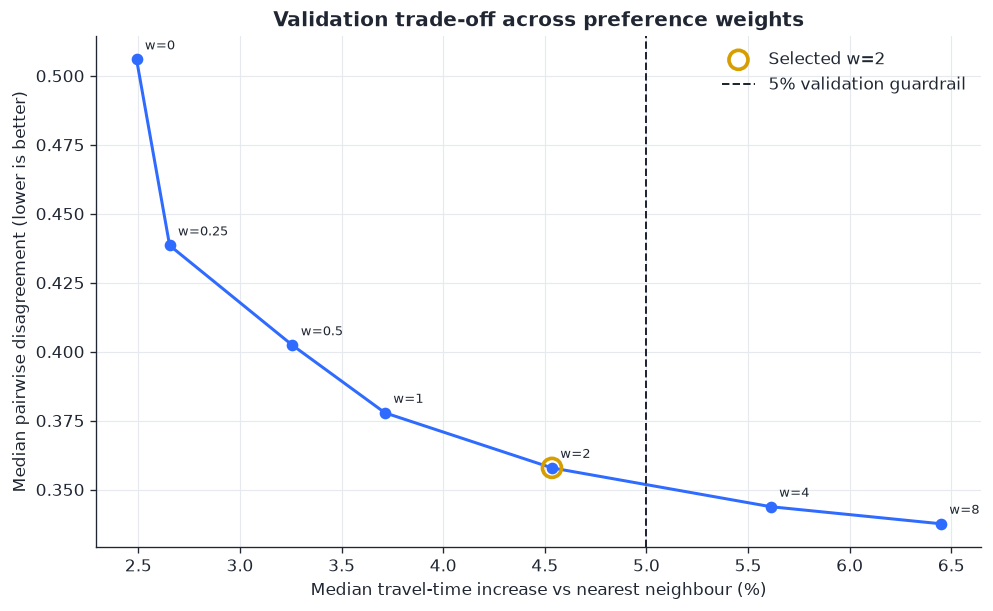

,preference_weight,routes,median_pairwise_disagreement,mean_pairwise_disagreement,median_travel_time_increase_fraction,mean_travel_time_increase_fraction,median_edge_recall,median_zone_reentries,median_runtime_ms,median_official_score,mean_official_score
0,0.00,916,0.50594,0.50035,0.02491,0.03625,0.54598,0.0,2.61130,0.06721,0.07385
1,0.25,916,0.43850,0.45205,0.02654,0.03800,0.54599,0.0,2.51585,0.06688,0.07234
2,0.50,916,0.40230,0.42259,0.03258,0.04154,0.54671,0.0,2.52215,0.06572,0.07080
3,1.00,916,0.37782,0.39597,0.03714,0.04654,0.54709,0.0,2.54340,0.06288,0.06897
4,2.00,916,0.35786,0.37569,0.04535,0.05406,0.54655,0.0,2.53060,0.06129,0.06788
5,4.00,916,0.34378,0.36340,0.05612,0.06491,0.54545,0.0,2.51260,0.06316,0.06858
6,8.00,916,0.33760,0.36595,0.06449,0.07762,0.54703,0.0,2.52460,0.06528,0.07025


In [2]:
pref_validation = validation.loc[validation["method"] == "pairwise_zone"].copy()
official_by_weight = (
    pref_validation.groupby("preference_weight", as_index=False)
    .agg(
        median_official_score=("official_route_score", "median"),
        mean_official_score=("official_route_score", "mean"),
    )
)
tradeoff = validation_weights.merge(official_by_weight, on="preference_weight", validate="one_to_one")
tradeoff.to_csv(OUT / "validation_tradeoff.csv", index=False)

fig, ax = plt.subplots(figsize=(8.4, 5.2))
x = 100 * tradeoff["median_travel_time_increase_fraction"]
y = tradeoff["median_pairwise_disagreement"]
ax.plot(x, y, color=BLUE, marker="o", linewidth=1.8, markersize=6)
for row, x_value, y_value in zip(tradeoff.itertuples(), x, y):
    ax.annotate(f"w={row.preference_weight:g}", (x_value, y_value), xytext=(5, 6), textcoords="offset points", fontsize=8)
selected = tradeoff.loc[tradeoff["preference_weight"] == selected_weight].iloc[0]
ax.scatter(
    100 * selected["median_travel_time_increase_fraction"],
    selected["median_pairwise_disagreement"],
    s=130,
    facecolors="none",
    edgecolors=GOLD,
    linewidths=2.2,
    label=f"Selected w={selected_weight:g}",
    zorder=4,
)
ax.axvline(5, color=INK, linestyle="--", linewidth=1.2, label="5% validation guardrail")
ax.set_title("Validation trade-off across preference weights")
ax.set_xlabel("Median travel-time increase vs nearest neighbour (%)")
ax.set_ylabel("Median pairwise disagreement (lower is better)")
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="both", color="#E6E9EE", linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "validation_tradeoff.png", bbox_inches="tight")
plt.show()

display(tradeoff.round(5))

### 2. Untouched test-set comparison

The comparison is paired by route. Bootstrap uncertainty resamples routes, preserving all metrics for a route together.

In [3]:
method_summary = (
    test.groupby("method", as_index=False)
    .agg(
        routes=("route_id", "nunique"),
        official_score_median=("official_route_score", "median"),
        official_score_mean=("official_route_score", "mean"),
        pairwise_disagreement_median=("pairwise_disagreement", "median"),
        travel_time_seconds_median=("travel_time_seconds", "median"),
        zone_reentries_median=("zone_reentries", "median"),
        runtime_ms_median=("runtime_ms", "median"),
    )
)
method_summary.to_csv(OUT / "test_method_summary.csv", index=False)
display(method_summary.round(5))

wide = test.pivot(index="route_id", columns="method")
official_delta = wide["official_route_score"]["pairwise_zone"] - wide["official_route_score"]["nearest_neighbor"]
travel_increase = (
    wide["travel_time_seconds"]["pairwise_zone"] / wide["travel_time_seconds"]["nearest_neighbor"] - 1
)

rng = np.random.default_rng(20260711)
values = official_delta.to_numpy()
bootstrap_medians = np.median(
    rng.choice(values, size=(10_000, len(values)), replace=True), axis=1
)
ci_low, ci_high = np.quantile(bootstrap_medians, [0.025, 0.975])

nn = method_summary.set_index("method").loc["nearest_neighbor"]
pairwise = method_summary.set_index("method").loc["pairwise_zone"]
headline = {
    "test_routes": int(len(values)),
    "selected_preference_weight": selected_weight,
    "official_score_median_nearest_neighbor": float(nn["official_score_median"]),
    "official_score_median_pairwise_zone": float(pairwise["official_score_median"]),
    "aggregate_median_score_reduction_fraction": float(
        1 - pairwise["official_score_median"] / nn["official_score_median"]
    ),
    "paired_median_official_score_delta": float(np.median(values)),
    "paired_median_delta_bootstrap_95_ci": [float(ci_low), float(ci_high)],
    "route_fraction_improved": float(np.mean(values < 0)),
    "median_travel_time_increase_fraction": float(np.median(travel_increase)),
    "median_zone_reentry_reduction": float(
        wide["zone_reentries"]["nearest_neighbor"].median()
        - wide["zone_reentries"]["pairwise_zone"].median()
    ),
}
(OUT / "headline_metrics.json").write_text(json.dumps(headline, indent=2), encoding="utf-8")
print(json.dumps(headline, indent=2))

,method,routes,official_score_median,official_score_mean,pairwise_disagreement_median,travel_time_seconds_median,zone_reentries_median,runtime_ms_median
0,angular_zone,926,0.09778,0.10335,0.50629,13021.45,0.0,0.28180
1,nearest_neighbor,926,0.10110,0.11602,0.49528,11188.80,21.0,1.35635
2,observed_driver,926,0.00000,0.00000,0.00000,10820.45,2.0,0.00000
3,pairwise_zone,926,0.06071,0.06794,0.33425,11740.00,0.0,2.27030


{
  "test_routes": 926,
  "selected_preference_weight": 2.0,
  "official_score_median_nearest_neighbor": 0.1010960164497587,
  "official_score_median_pairwise_zone": 0.06071055283348625,
  "aggregate_median_score_reduction_fraction": 0.3994763100912354,
  "paired_median_official_score_delta": -0.0421308832494161,
  "paired_median_delta_bootstrap_95_ci": [
    -0.0449610807755223,
    -0.040425518827084186
  ],
  "route_fraction_improved": 0.8812095032397408,
  "median_travel_time_increase_fraction": 0.04828670472171226,
  "median_zone_reentry_reduction": 21.0
}


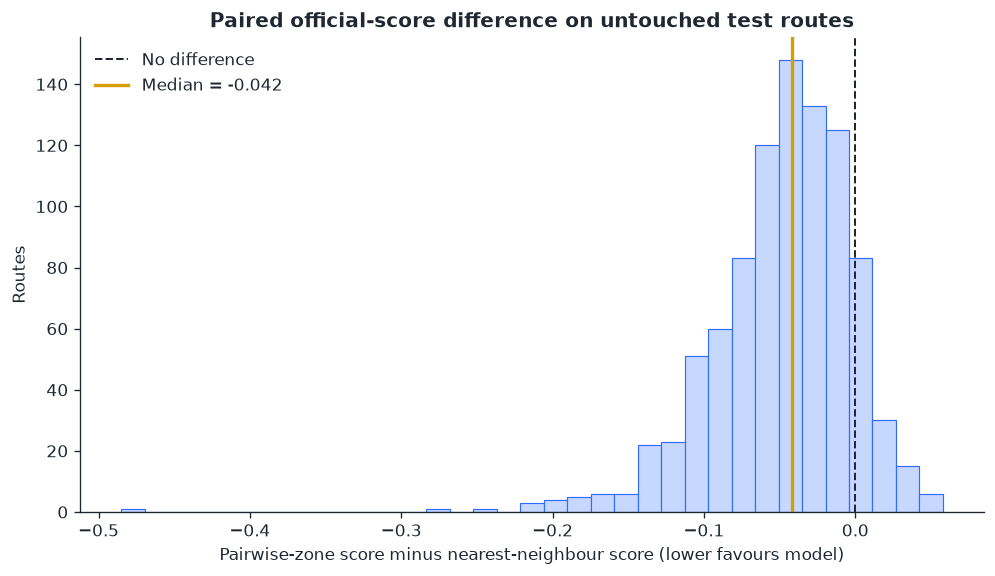

In [4]:
fig, ax = plt.subplots(figsize=(8.4, 4.9))
ax.hist(official_delta, bins=35, color=LIGHT_BLUE, edgecolor=BLUE, linewidth=0.7)
ax.axvline(0, color=INK, linestyle="--", linewidth=1.2, label="No difference")
ax.axvline(official_delta.median(), color=GOLD, linewidth=2, label=f"Median = {official_delta.median():.3f}")
ax.set_title("Paired official-score difference on untouched test routes")
ax.set_xlabel("Pairwise-zone score minus nearest-neighbour score (lower favours model)")
ax.set_ylabel("Routes")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "paired_official_score_delta.png", bbox_inches="tight")
plt.show()

### 3. Operational trade-off at route level

Each point is one untouched test route. The lower-right quadrant means the learned route is more driver-like by the official score but slower than nearest neighbour; the lower-left quadrant improves both quantities.

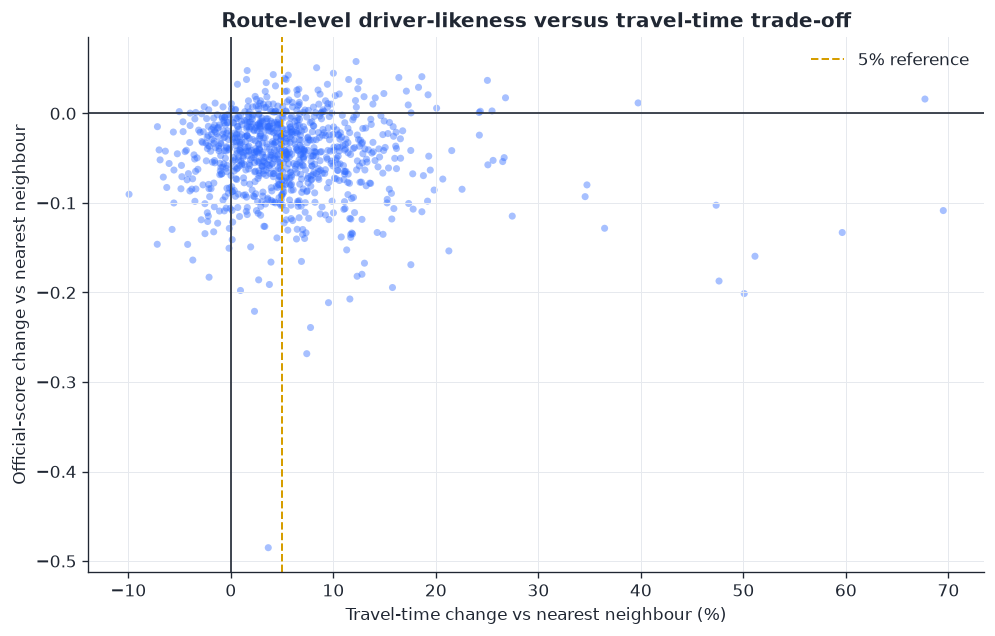

In [5]:
fig, ax = plt.subplots(figsize=(8.4, 5.4))
ax.scatter(100 * travel_increase, official_delta, s=18, alpha=0.42, color=BLUE, edgecolors="none")
ax.axhline(0, color=INK, linewidth=1)
ax.axvline(0, color=INK, linewidth=1)
ax.axvline(5, color=GOLD, linestyle="--", linewidth=1.2, label="5% reference")
ax.set_title("Route-level driver-likeness versus travel-time trade-off")
ax.set_xlabel("Travel-time change vs nearest neighbour (%)")
ax.set_ylabel("Official-score change vs nearest neighbour")
ax.legend(frameon=False)
ax.grid(color="#E6E9EE", linewidth=0.6)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "route_level_tradeoff.png", bbox_inches="tight")
plt.show()

### 4. Station heterogeneity

Aggregate gains can hide where a learned preference model transfers poorly. Station estimates below are descriptive because no station-specific hypothesis was pre-registered.

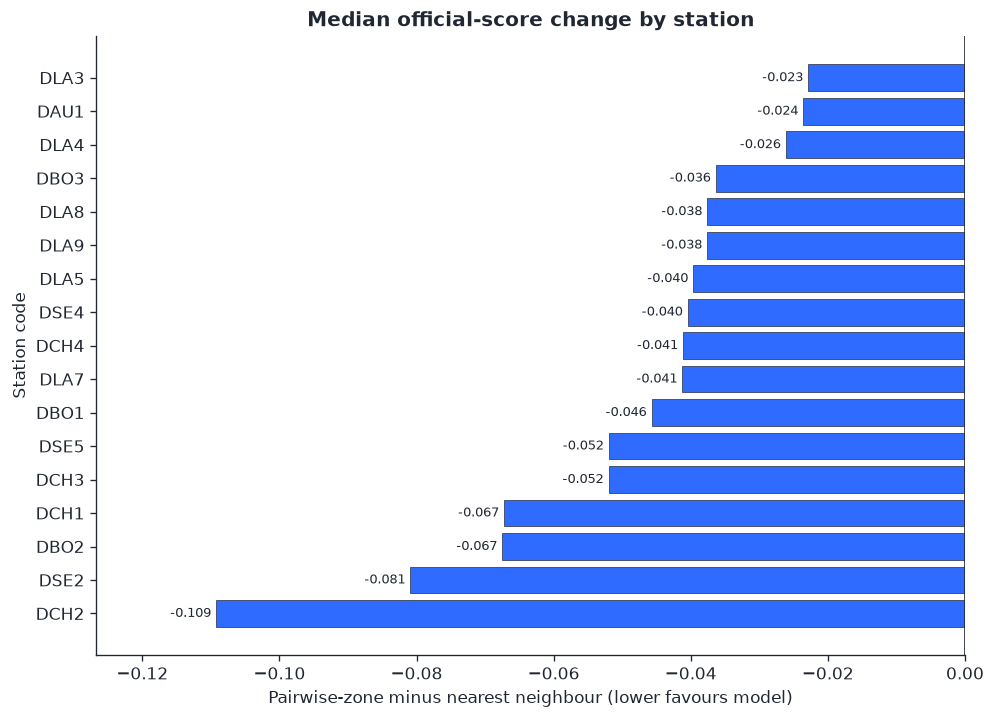

,station_code,routes,median_official_delta,mean_official_delta,improved_fraction
5,DCH2,24,-0.1092,-0.1275,0.9583
14,DSE2,19,-0.0809,-0.0819,1.0000
2,DBO2,45,-0.0675,-0.0696,0.8667
4,DCH1,30,-0.0672,-0.0744,0.9667
6,DCH3,41,-0.0520,-0.0546,0.8780
16,DSE5,77,-0.0520,-0.0548,0.9091
1,DBO1,9,-0.0457,-0.0544,1.0000
11,DLA7,170,-0.0412,-0.0423,0.9118
7,DCH4,58,-0.0411,-0.0397,0.8448
15,DSE4,67,-0.0404,-0.0459,0.9104


In [6]:
route_context = test.drop_duplicates("route_id").set_index("route_id")[["station_code"]]
station = pd.DataFrame({"official_delta": official_delta}).join(route_context)
station_summary = (
    station.groupby("station_code", as_index=False)
    .agg(
        routes=("official_delta", "size"),
        median_official_delta=("official_delta", "median"),
        mean_official_delta=("official_delta", "mean"),
        improved_fraction=("official_delta", lambda x: float((x < 0).mean())),
    )
    .sort_values("median_official_delta")
)
station_summary.to_csv(OUT / "station_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(8.4, 6.1))
colors = [BLUE if value < 0 else GOLD for value in station_summary["median_official_delta"]]
bars = ax.barh(station_summary["station_code"], station_summary["median_official_delta"], color=colors, edgecolor=INK, linewidth=0.4)
ax.axvline(0, color=INK, linewidth=1)
ax.set_xlim(1.16 * station_summary["median_official_delta"].min(), 0)
ax.bar_label(bars, labels=[f"{value:.3f}" for value in station_summary["median_official_delta"]], padding=3, fontsize=8)
ax.set_title("Median official-score change by station")
ax.set_xlabel("Pairwise-zone minus nearest neighbour (lower favours model)")
ax.set_ylabel("Station code")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "station_heterogeneity.png", bbox_inches="tight")
plt.show()

display(station_summary.round(4))

## Takeaways

- The learned zone-preference model materially improves driver-likeness on the untouched chronological test set, including the official challenge score.
- The gain is not free: the selected model accepts a small median supplied-travel-time increase relative to nearest neighbour, within the validation guardrail used for selection.
- Enforcing zone exhaustion eliminates median zone re-entry, producing more coherent delivery-zone blocks.
- Results vary by station; deployment should retain station-level monitoring and a distance-only fallback.

## Limitations

- Historical driver sequences are demonstrations, not proof of optimal or preferred routes.
- The observational dataset does not identify causal effects on driver workload, service time, or delivery success.
- Package time windows and service duration are not yet embedded as hard feasibility constraints.
- The official sequence-deviation component has known permutation edge cases (for example, an exact reverse traversal can receive zero sequence deviation); conclusions therefore use it alongside pairwise disagreement, travel time, and zone re-entry.
- Data are from a short 2018 window and 17 US delivery stations; external validity is untested.